In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy

In [2]:
class SymbolicModel:
  def __init__(self):
    self.delta_uu, self.delta_ud, self.delta_du, self.delta_dd = sp.symbols(
      r"\Delta_{\uparrow\uparrow}, \Delta_{\uparrow\downarrow}, \Delta_{\downarrow\uparrow}, \Delta_{\downarrow\downarrow}",
      complex=True,
    )
    self.delta_pp, self.delta_pm, self.delta_mp, self.delta_mm = sp.symbols(
      r"\Delta_{++}, \Delta_{+-}, \Delta_{-+}, \Delta_{--}", complex=True
    )
    self.alpha_R = sp.symbols(r"\alpha_R")
    self.t_hop = sp.symbols(r"t_{hop}")
    self.kx, self.ky = sp.symbols(r"k_x, k_y", real=True)
    self.theta_k, self.k = sp.symbols(r"\theta_k k", real=True, positive=True)
    self.s_x = sp.Matrix([[0, 1], [1, 0]])
    self.s_y = sp.Matrix([[0, -sp.I], [sp.I, 0]])
    self.s_z = sp.Matrix([[1, 0], [0, -1]])
    self.s_0 = sp.Matrix([[1, 0], [0, 1]])

  def get_hamiltonian(self):
    # Kinetic term (parabolic)
    # H_kin = ((kx**2 + ky**2) / (2)) * s_0
    H_kin = -self.t_hop * (sp.cos(self.kx) + sp.cos(self.ky)) * self.s_0
    # Rashba term
    H_Rashba = self.alpha_R * (self.kx * (-self.s_y) + self.ky * self.s_x)  # alpha*(ky*sigma_x - kx*sigma_y)

    # Total Hamiltonian
    H_total = H_kin + H_Rashba

    # Simplify
    H_total = sp.simplify(H_total)

    # Display
    display(H_total)
    return H_total

  def get_u_k_minus_k(self, H_total):
    U_elec, H_diag = H_total.diagonalize()
    display(sp.simplify(U_elec))
    display(H_diag)

    polar_subs = {self.kx: self.k * sp.cos(self.theta_k), self.ky: self.k * sp.sin(self.theta_k)}
    U_k_polar = U_elec.subs(polar_subs)
    U_k_polar = sp.simplify(U_k_polar)
    display(U_k_polar)
    # Define delta in band basis

    U_minus_k = U_k_polar.subs(self.theta_k, sp.pi + self.theta_k)
    display(U_minus_k)
    return U_k_polar, U_minus_k

  def lambdify_u_k_minus_k(self, U_k, U_minus_k):
    U_k_func = sp.lambdify((self.theta_k), U_k, "numpy", cse=True)
    U_minus_k_func = sp.lambdify((self.theta_k), U_minus_k, "numpy", cse=True)
    return U_k_func, U_minus_k_func

  def lambdify_hamiltonian(self, H_total):
    H_func = sp.lambdify((self.kx, self.ky, self.t_hop, self.alpha_R), H_total, "numpy", cse=True)
    return H_func

In [3]:
""" Pauli matrices """
s_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
s_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
s_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)
s_0 = np.array([[1, 0], [0, 1]], dtype=np.complex128)


In [4]:
""" Symbolic model """
model = SymbolicModel()
H_total = model.get_hamiltonian()
U_k, U_minus_k = model.get_u_k_minus_k(H_total)
U_k_func, U_minus_k_func = model.lambdify_u_k_minus_k(U_k, U_minus_k)
H_k_func = model.lambdify_hamiltonian(H_total)

Matrix([
[-t_{hop}*(cos(k_x) + cos(k_y)),         \alpha_R*(I*k_x + k_y)],
[       \alpha_R*(-I*k_x + k_y), -t_{hop}*(cos(k_x) + cos(k_y))]])

Matrix([
[(-I*k_x - k_y)/sqrt(k_x**2 + k_y**2), (I*k_x + k_y)/sqrt(k_x**2 + k_y**2)],
[                                   1,                                   1]])

Matrix([
[-\alpha_R*sqrt(k_x**2 + k_y**2) - t_{hop}*(cos(k_x) + cos(k_y)),                                                              0],
[                                                              0, \alpha_R*sqrt(k_x**2 + k_y**2) - t_{hop}*(cos(k_x) + cos(k_y))]])

Matrix([
[-sin(\theta_k) - I*cos(\theta_k), sin(\theta_k) + I*cos(\theta_k)],
[                               1,                               1]])

Matrix([
[sin(\theta_k) + I*cos(\theta_k), -sin(\theta_k) - I*cos(\theta_k)],
[                              1,                                1]])

In [5]:
""" Quick checkers """


def apply_spin_time_reversal_operator_to_basis(A):
  return (-1j * s_y) @ np.conjugate(A)


def simplify_output(M, threshold=1e-6):
  # Round small real and imaginary parts to zero
  # Method 1: Using np.where (cleanest)
  M = np.where(np.abs(M) < threshold, 0, M)

  # Method 2: Separate real and imaginary parts
  M.real[np.abs(M.real) < threshold] = 0
  M.imag[np.abs(M.imag) < threshold] = 0
  return M


def check_fermionic_antisymmetry(Delta_k, Delta_minus_k):
  # Check if Delta(-k) = -Delta(k)^T
  if np.allclose(-np.transpose(Delta_minus_k), Delta_k, atol=1e-3):
    return True
  else:
    print("ERROR: Fermionic antisymmetry violated!")
    print("Delta")
    print(simplify_output(Delta_k))
    print("Delta_minus_k")
    print(simplify_output(Delta_minus_k))
  return False


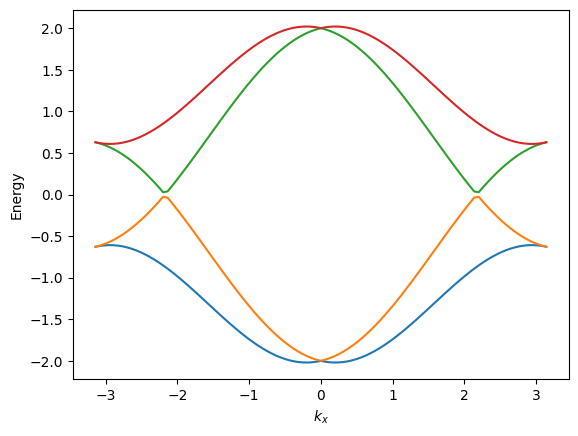

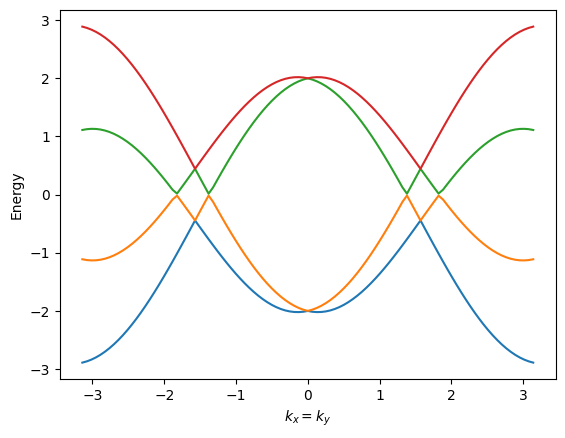

In [6]:
""" Plot dispersion relation """
t = 1
alpha = 2e-1
k_pts = np.linspace(-np.pi, np.pi, 101)
Energies_plot = []
for kx in k_pts:
  H_elec = H_k_func(kx, 0, t, alpha)
  H_hole = -np.conjugate((H_k_func(-kx, 0, t, alpha)))
  H_bdg = scipy.linalg.block_diag(H_elec, H_hole)
  Energies, eigenvectors = np.linalg.eigh(H_bdg)
  Energies_plot.append(Energies)

plt.xlabel(r"$k_x$")
plt.ylabel(r"Energy")
plt.plot(k_pts, Energies_plot)
plt.show()

Energies_plot = []
for kx in k_pts:
  H_elec = H_k_func(kx, kx, t, alpha)
  H_hole = -np.conjugate((H_k_func(-kx, -kx, t, alpha)))
  H_bdg = scipy.linalg.block_diag(H_elec, H_hole)
  Energies, eigenvectors = np.linalg.eigh(H_bdg)
  Energies_plot.append(Energies)

plt.xlabel(r"$k_x = k_y$")
plt.ylabel(r"Energy")
plt.plot(k_pts, Energies_plot)
plt.show()

In [7]:
def calculate_analytical_U(kx, ky):
  phase = np.arctan2(ky, kx)
  U = U_k_func(phase)
  U_minus_k = U_minus_k_func(phase)

  # Normalize columns
  U[:, 0] /= np.linalg.norm(U[:, 0]) ** 2
  U[:, 1] /= np.linalg.norm(U[:, 1]) ** 2
  U_minus_k[:, 0] /= np.linalg.norm(U_minus_k[:, 0]) ** 2
  U_minus_k[:, 1] /= np.linalg.norm(U_minus_k[:, 1]) ** 2

  return U, U_minus_k


def delta_analytical_transform(kx, ky, Delta):
  U, U_minus_k = calculate_analytical_U(kx, ky)
  Delta_new = np.zeros((2, 2), dtype=np.complex128)
  Delta_new = U @ Delta @ np.transpose(U_minus_k)

  Delta_new_minus_k = U_minus_k @ Delta @ np.transpose(U)
  check_fermionic_antisymmetry(Delta_new, Delta_new_minus_k)

  return Delta_new


In [8]:
def calculate_delta_map_analytical(t, alpha, k_pts, Delta_pairing, hermitian=True):
  # Store Delta_k values in a 2D grid
  Delta_grid = np.zeros((len(k_pts), len(k_pts), 2, 2), dtype=np.complex128)

  for i, kx in enumerate(k_pts):
    for j, ky in enumerate(k_pts):
      Delta = delta_analytical_transform(kx, ky, Delta_pairing)
      Delta_grid[i, j] = Delta
  return Delta_grid


def calculate_delta_map_trs(t, alpha, k_pts, Delta_pairing, hermitian=True):
  # Store Delta_k values in a 2D grid
  Delta_grid = np.zeros((len(k_pts), len(k_pts), 2, 2), dtype=np.complex128)

  for i, kx in enumerate(k_pts):
    for j, ky in enumerate(k_pts):
      H_elec = H_k_func(kx, ky, t, alpha)
      if hermitian:
        _, U_elec = np.linalg.eigh(H_elec)
      else:
        _, U_elec = np.linalg.eig(H_elec)
      # Enforcing time-reversal symmetry by hand
      U_hole = apply_spin_time_reversal_operator_to_basis(U_elec)

      Delta = U_elec @ Delta_pairing @ U_hole.T  # np.transpose(U_hole)
      Delta_minus_k = U_hole @ Delta_pairing @ np.transpose(apply_spin_time_reversal_operator_to_basis(U_hole))

      check_fermionic_antisymmetry(Delta, Delta_minus_k)

      Delta_grid[i, j] = Delta

  return Delta_grid


def calculate_delta_map_naive(t, alpha, k_pts, Delta_pairing, hermitian=True):
  # Store Delta_k values in a 2D grid
  Delta_grid = np.zeros((len(k_pts), len(k_pts), 2, 2), dtype=np.complex128)

  for i, kx in enumerate(k_pts):
    for j, ky in enumerate(k_pts):
      H_elec = H_k_func(kx, ky, t, alpha)
      H_hole = H_k_func(-kx, -ky, t, alpha)
      # Check how the choice of eig vs eigh affects the results
      if hermitian:
        _, U_elec = np.linalg.eigh(H_elec)
        _, U_hole = np.linalg.eigh(H_hole)
      else:
        _, U_elec = np.linalg.eig(H_elec)
        _, U_hole = np.linalg.eig(H_hole)

      Delta = U_elec @ Delta_pairing @ np.transpose(U_hole)
      Delta_grid[i, j] = Delta
  return Delta_grid

In [9]:
def plot_delta_maps(Delta_grid, n_max=1, m_max=1):
  """
  Plot Delta maps in matrix layout: for each (n,m), show 2x2 grid of
  [ABS, PHASE; RE, IM] with increased spacing between different (n,m) blocks.
  """
  n_vals = range(n_max + 1)
  m_vals = range(m_max + 1)

  # Calculate height/width ratios to create gaps between blocks
  height_ratios = []
  for n in range(n_max + 1):
    height_ratios.append(1)  # First row of block
    height_ratios.append(1)  # Second row of block
    if n < n_max:
      height_ratios.append(0.3)  # Gap between n blocks

  width_ratios = []
  for m in range(m_max + 1):
    width_ratios.append(1)  # First col of block
    width_ratios.append(1)  # Second col of block
    if m < m_max:
      width_ratios.append(0.3)  # Gap between m blocks

  n_rows = len(height_ratios)
  n_cols = len(width_ratios)

  fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))
  gs = fig.add_gridspec(
    n_rows, n_cols, height_ratios=height_ratios, width_ratios=width_ratios, hspace=0.15, wspace=0.30
  )

  for n in n_vals:
    for m in m_vals:
      Delta_nm = Delta_grid[:, :, n, m]

      # Calculate grid indices accounting for gaps
      row_base = n * 3 if n > 0 else 0
      col_base = m * 3 if m > 0 else 0

      # Create 4 subplots: [ABS, PHASE; RE, IM]
      ax_abs = fig.add_subplot(gs[row_base, col_base])
      ax_phase = fig.add_subplot(gs[row_base, col_base + 1])
      ax_re = fig.add_subplot(gs[row_base + 1, col_base])
      ax_im = fig.add_subplot(gs[row_base + 1, col_base + 1])

      # Absolute value
      im_abs = ax_abs.imshow(
        np.transpose(np.abs(Delta_nm)), origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi], cmap="viridis"
      )
      ax_abs.set_xlabel("kx", fontsize=10)
      ax_abs.set_ylabel("ky", fontsize=10)
      ax_abs.set_title(rf"$|\Delta_{{{n}{m}}}(k)|$", fontsize=12, pad=8)
      ax_abs.tick_params(labelsize=9)

      # Phase
      im_phase = ax_phase.imshow(
        np.transpose(np.angle(Delta_nm)) / np.pi, origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi], cmap="hsv"
      )
      ax_phase.set_xlabel("kx", fontsize=10)
      ax_phase.set_ylabel("ky", fontsize=10)
      ax_phase.set_title(rf"$\arg(\Delta_{{{n}{m}}}(k))/\pi$", fontsize=12, pad=8)
      ax_phase.tick_params(labelsize=9)

      # Real part
      im_re = ax_re.imshow(
        np.transpose(np.real(Delta_nm)), origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi], cmap="RdBu_r"
      )
      ax_re.set_xlabel("kx", fontsize=10)
      ax_re.set_ylabel("ky", fontsize=10)
      ax_re.set_title(rf"$\Re(\Delta_{{{n}{m}}}(k))$", fontsize=12, pad=8)
      ax_re.tick_params(labelsize=9)

      # Imaginary part
      im_im = ax_im.imshow(
        np.transpose(np.imag(Delta_nm)), origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi], cmap="RdBu_r"
      )
      ax_im.set_xlabel("kx", fontsize=10)
      ax_im.set_ylabel("ky", fontsize=10)
      ax_im.set_title(rf"$\Im(\Delta_{{{n}{m}}}(k))$", fontsize=12, pad=8)
      ax_im.tick_params(labelsize=9)

      # Add colorbars with proper formatting
      from matplotlib.ticker import ScalarFormatter, FuncFormatter

      def format_func(x, pos):
        if abs(x) < 1e-10:
          return "0.0"
        return f"{x:.2f}"

      formatter_exp = FuncFormatter(format_func)

      formatter_phase = ScalarFormatter(useMathText=True)
      formatter_phase.set_scientific(False)

      cbar_abs = fig.colorbar(im_abs, ax=ax_abs, fraction=0.046, pad=0.04, format=formatter_exp)
      cbar_phase = fig.colorbar(im_phase, ax=ax_phase, fraction=0.046, pad=0.04, format=formatter_phase)
      cbar_re = fig.colorbar(im_re, ax=ax_re, fraction=0.046, pad=0.04, format=formatter_exp)
      cbar_im = fig.colorbar(im_im, ax=ax_im, fraction=0.046, pad=0.04, format=formatter_exp)

  plt.tight_layout()
  plt.show()


 ==== Results for calculate_delta_map_trs ==== 


/tmp/ipykernel_2947570/2309332722.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


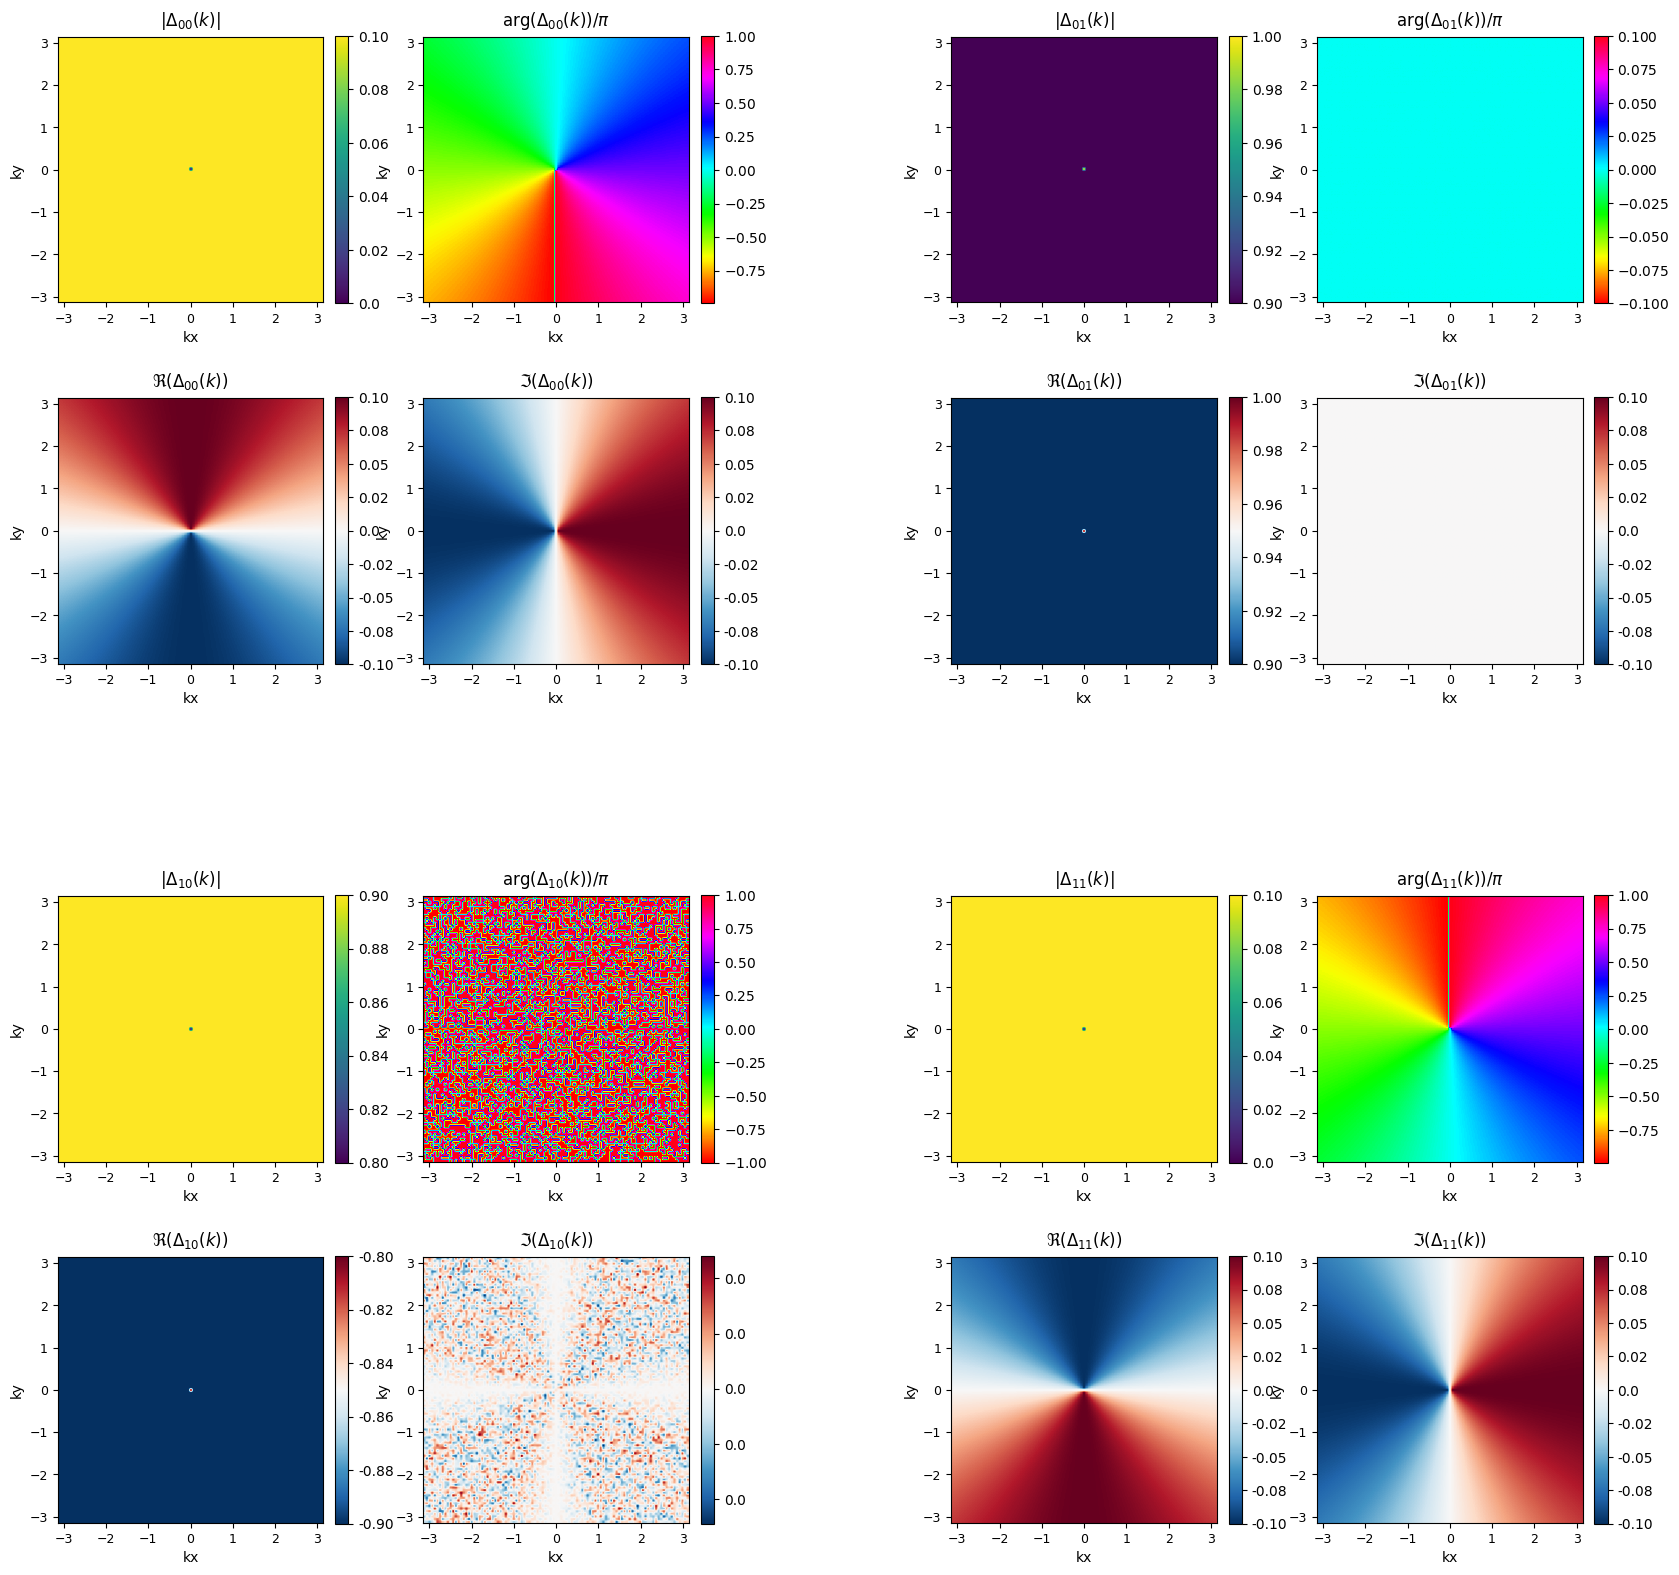

In [16]:
function_cbs = (calculate_delta_map_trs,)
t = 1
alpha = 2e-1
k_pts = np.linspace(-np.pi, np.pi, 101)
Delta_pairing = np.array([[1, 0], [0, 0.8]], dtype=np.complex128)

for func in function_cbs:
  print(f" ==== Results for {func.__name__} ==== ")
  Delta_grid = func(t, alpha, k_pts, Delta_pairing)
  plot_delta_maps(Delta_grid)

  # print(simplify_output(Delta_grid))

In [11]:
def fourier_transform_to_real_space(Delta_grid, k_pts, neighbors):
  Delta_real_space = np.zeros((len(neighbors), 2, 2), dtype=np.complex128)
  dk2 = np.pi**2 / (len(k_pts) ** 2)
  for i, kx in enumerate(k_pts):
    for j, ky in enumerate(k_pts):
      k_vec = np.array([kx, ky])
      Delta = Delta_grid[i, j]
      for i_neighbor, neighbor in enumerate(neighbors):
        phase = np.exp(1j * np.dot(neighbor, k_vec))
        Delta_real_space[i_neighbor] += Delta * phase * dk2

  return Delta_real_space


In [12]:
def plot_pairing_amplitudes(Delta_real_space, n_max, m_max, neighbors):
  """
  Plot pairing amplitudes in matrix layout: for each (n,m), show 2x2 grid of
  [ABS, PHASE; RE, IM] with increased spacing between different (n,m) blocks.
  """
  n_vals = range(n_max + 1)
  m_vals = range(m_max + 1)

  # Calculate height/width ratios to create gaps between blocks
  height_ratios = []
  for n in range(n_max + 1):
    height_ratios.append(1)  # First row of block
    height_ratios.append(1)  # Second row of block
    if n < n_max:
      height_ratios.append(0.3)  # Gap between n blocks

  width_ratios = []
  for m in range(m_max + 1):
    width_ratios.append(1)  # First col of block
    width_ratios.append(1)  # Second col of block
    if m < m_max:
      width_ratios.append(0.3)  # Gap between m blocks

  n_rows = len(height_ratios)
  n_cols = len(width_ratios)

  fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))
  gs = fig.add_gridspec(
    n_rows, n_cols, height_ratios=height_ratios, width_ratios=width_ratios, hspace=0.15, wspace=0.30
  )

  for n in n_vals:
    for m in m_vals:
      Delta_nm = Delta_real_space[:, n, m]

      amplitudes = np.abs(Delta_nm)
      phases = np.angle(Delta_nm) / np.pi
      real_part = np.real(Delta_nm)
      imag_part = np.imag(Delta_nm)

      # Normalizations
      norm_amp = plt.Normalize(vmin=amplitudes.min(), vmax=amplitudes.max())
      norm_phase = plt.Normalize(vmin=-1.0, vmax=1.0)
      max_reim = np.max(np.abs(np.concatenate([real_part, imag_part])))
      norm_reim = plt.Normalize(vmin=-max_reim, vmax=max_reim)

      # Colormaps
      cmap_amp = plt.cm.viridis
      cmap_phase = plt.cm.hsv
      cmap_reim = plt.cm.RdBu_r

      # Calculate grid indices accounting for gaps
      row_base = n * 3 if n > 0 else 0
      col_base = m * 3 if m > 0 else 0

      # Create 4 subplots: [ABS, PHASE; RE, IM]
      ax_abs = fig.add_subplot(gs[row_base, col_base])
      ax_phase = fig.add_subplot(gs[row_base, col_base + 1])
      ax_re = fig.add_subplot(gs[row_base + 1, col_base])
      ax_im = fig.add_subplot(gs[row_base + 1, col_base + 1])

      def draw(ax, values, cmap, norm, title):
        for i, neighbor in enumerate(neighbors):
          color = cmap(norm(values[i]))
          ax.arrow(0, 0, neighbor[0], neighbor[1], head_width=0.15, head_length=0.1, fc=color, ec=color, linewidth=2)
          ax.scatter(neighbor[0], neighbor[1], c=[color], s=200, zorder=5)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.set_title(title, fontsize=12, pad=8)
        ax.tick_params(labelsize=9)

      draw(ax_abs, amplitudes, cmap_amp, norm_amp, rf"$|\Delta_{{{n}{m}}}|$")
      draw(ax_phase, phases, cmap_phase, norm_phase, rf"$\arg(\Delta_{{{n}{m}}})/\pi$")
      draw(ax_re, real_part, cmap_reim, norm_reim, rf"$\Re(\Delta_{{{n}{m}}})$")
      draw(ax_im, imag_part, cmap_reim, norm_reim, rf"$\Im(\Delta_{{{n}{m}}})$")

      # Add colorbars with proper exponential formatting
      from matplotlib.ticker import ScalarFormatter, FuncFormatter

      def format_func(x, pos):
        if abs(x) < 1e-10:
          return "0.0"
        return f"{x:.2f}"

      formatter_exp = FuncFormatter(format_func)

      formatter_phase = ScalarFormatter(useMathText=True)
      formatter_phase.set_scientific(False)

      cbar_abs = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap_amp, norm=norm_amp), ax=ax_abs, fraction=0.046, pad=0.04, format=formatter_exp
      )

      cbar_phase = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap_phase, norm=norm_phase),
        ax=ax_phase,
        fraction=0.046,
        pad=0.04,
        format=formatter_phase,
      )

      cbar_re = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap_reim, norm=norm_reim), ax=ax_re, fraction=0.046, pad=0.04, format=formatter_exp
      )

      cbar_im = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap_reim, norm=norm_reim), ax=ax_im, fraction=0.046, pad=0.04, format=formatter_exp
      )

  plt.tight_layout()
  plt.show()


In [13]:
neighbors = np.array([
  [0, 0],
  # 1st NN (r^2 = 1)
  [1, 0],
  [-1, 0],
  [0, 1],
  [0, -1],
  # 2nd NN (r^2 = 2)
  [1, 1],
  [-1, -1],
  [1, -1],
  [-1, 1],
  # 3rd NN (r^2 = 4)
  [2, 0],
  [-2, 0],
  [0, 2],
  [0, -2],
  # 4th NN (r^2 = 5)
  [2, 1],
  [2, -1],
  [-2, 1],
  [-2, -1],
  [1, 2],
  [1, -2],
  [-1, 2],
  [-1, -2],
  # 5th NN (r^2 = 8)
  # [2, 2],
  # [-2, -2],
  # [2, -2],
  # [-2, 2],
  # # 6th NN (r^2 = 9)
  # [3, 0],
  # [-3, 0],
  # [0, 3],
  # [0, -3],
  # # 7th NN (r^2 = 10)
  # [3, 1],
  # [3, -1],
  # [-3, 1],
  # [-3, -1],
  # [1, 3],
  # [1, -3],
  # [-1, 3],
  # [-1, -3],
  # # 8th NN (r^2 = 13)
  # [3, 2],
  # [3, -2],
  # [-3, 2],
  # [-3, -2],
  # [2, 3],
  # [2, -3],
  # [-2, 3],
  # [-2, -3],
  # # 9th NN (r^2 = 16)
  # [4, 0],
  # [-4, 0],
  # [0, 4],
  # [0, -4],
  # # 10th NN (r^2 = 17)
  # [4, 1],
  # [4, -1],
  # [-4, 1],
  # [-4, -1],
  # [1, 4],
  # [1, -4],
  # [-1, 4],
  # [-1, -4],
])


Fourier transform for calculate_delta_map_trs
Fourier transform to real space completed.


/tmp/ipykernel_2947570/3434229884.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


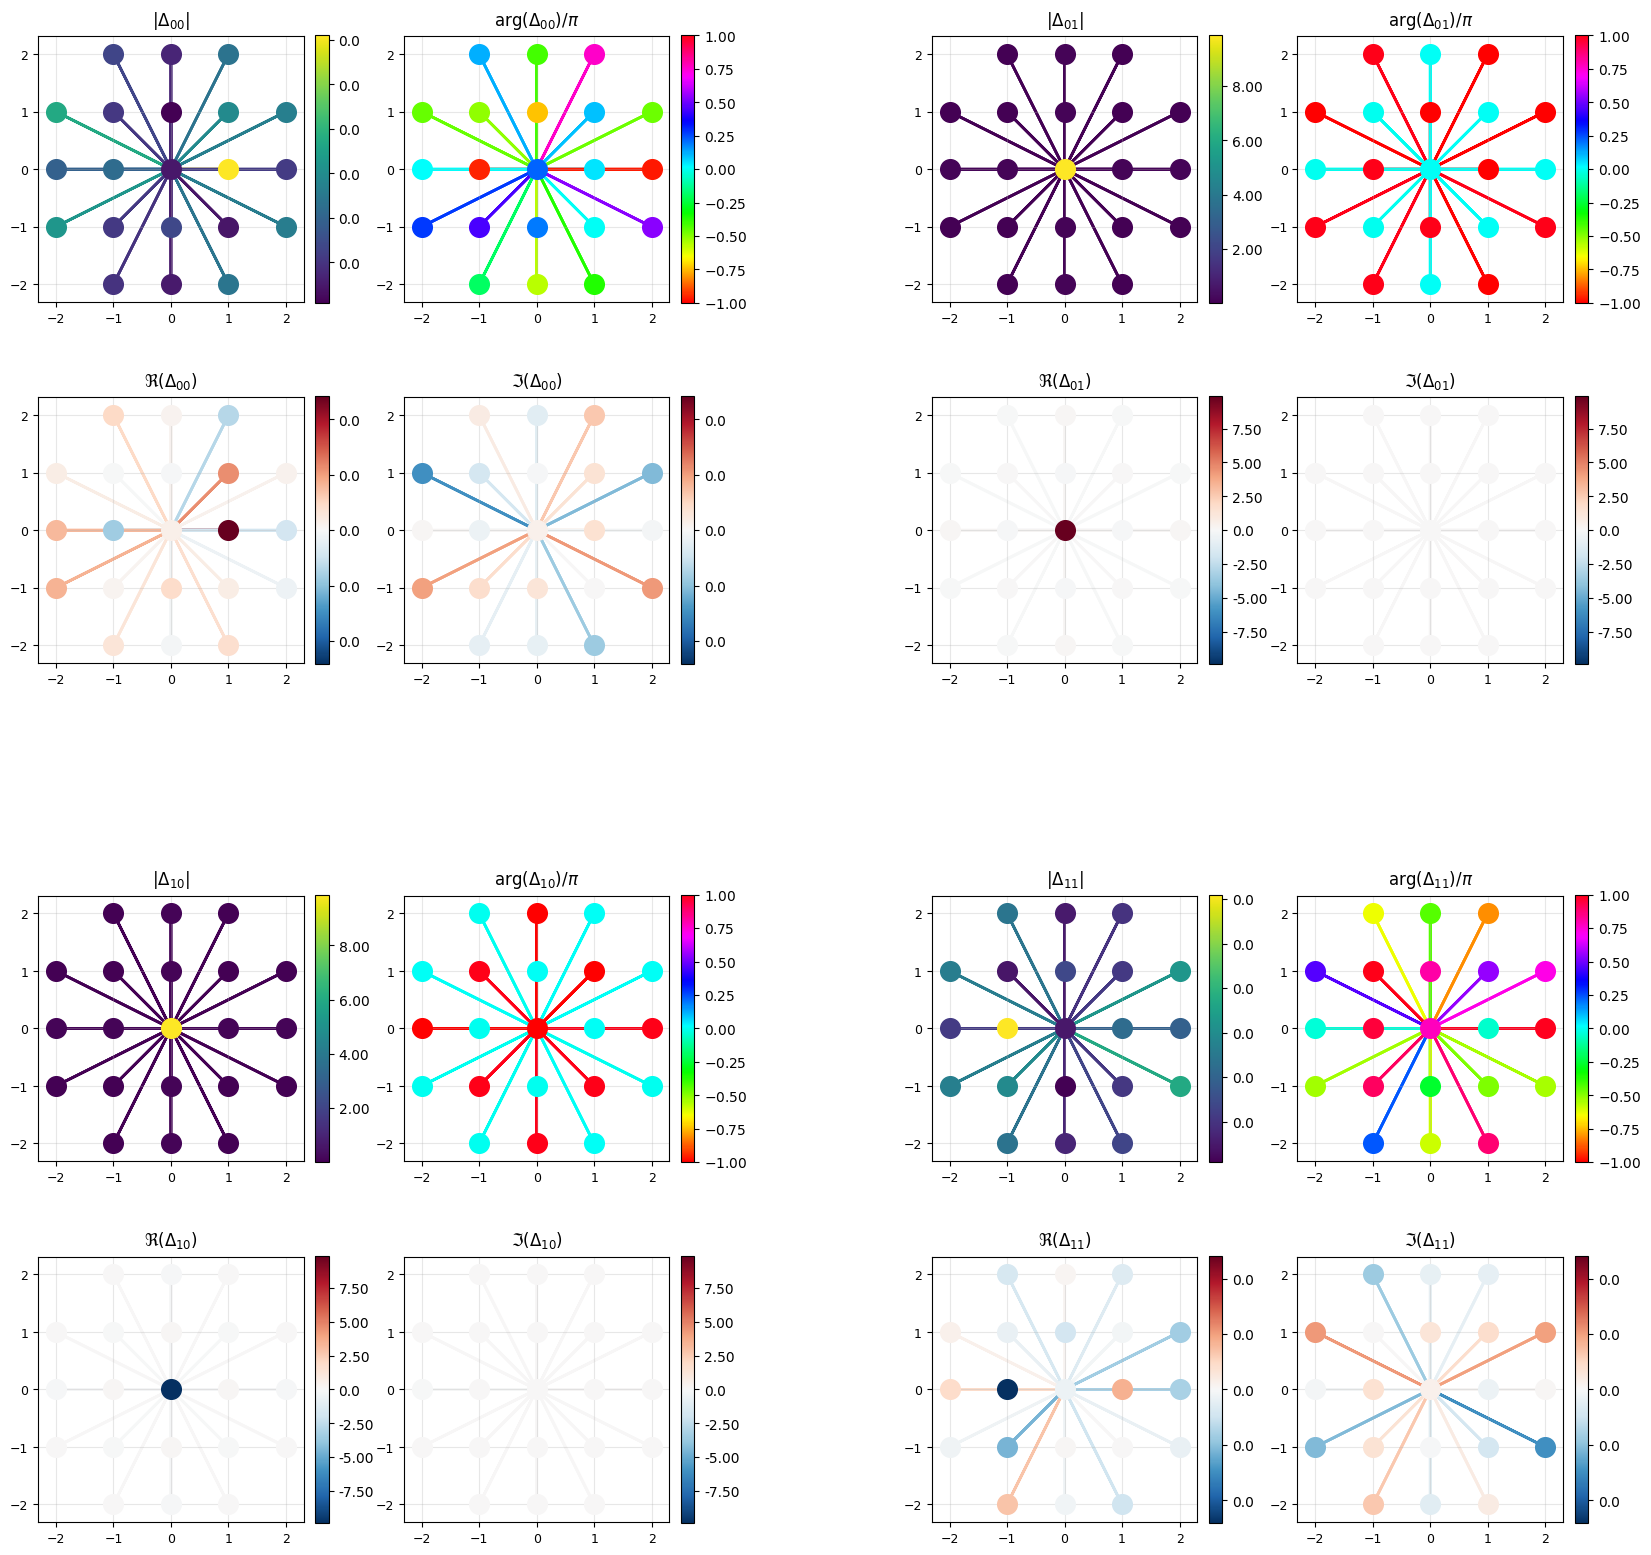

In [14]:
for func in function_cbs:
  Delta_grid = func(t, alpha, k_pts, Delta_pairing)
  print(f"Fourier transform for {func.__name__}")
  Delta_real_space = fourier_transform_to_real_space(Delta_grid, k_pts, neighbors)
  print("Fourier transform to real space completed.")
  # Usage example:
  plot_pairing_amplitudes(Delta_real_space, 1, 1, neighbors)
  # print(Delta_real_space)